# Robust Covariance Estimation with Tyler's Estimator

This notebook demonstrates how Tyler's M‑estimator produces a covariance matrix that is robust to outliers, leading to more stable minimum‑variance portfolios, especially during market crises.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from data_loader import fetch_asset_data, compute_returns
from tyler_estimator import tyler_estimator
from portfolio_optimizer import min_variance_portfolio
import visualization as viz

## 1. Load Data

We'll use a set of US stocks and a benchmark (SPY). The data period includes the March 2020 COVID crash to highlight robustness.

In [4]:
from data_loader import load_from_csv

# Load synthetic data that contains our engineered 'crash'
prices = load_from_csv('../data/synthetic_market_data.csv')

# Separate the benchmark (SPY) from our portfolio assets
symbols = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'JNJ', 'XOM', 'WMT']
portfolio_prices = prices[symbols]

returns = compute_returns(portfolio_prices)
returns.head()

,AAPL,MSFT,GOOGL,AMZN,JPM,JNJ,XOM,WMT
Date,,,,,,,,
2019-01-02,0.005627,-0.003879,-0.003901,0.002786,-0.017579,-0.015799,-0.004813,-0.009070
2019-01-03,-0.008080,-0.012845,0.014349,-0.001633,0.001138,-0.012963,-0.004644,0.001548
2019-01-04,0.004050,-0.005176,-0.002256,-0.005186,0.018002,0.000372,-0.009494,0.008272
2019-01-07,0.002474,-0.018017,-0.012050,0.002360,0.007478,0.002119,-0.000593,-0.002345
2019-01-08,-0.006302,-0.003853,0.010489,0.003747,-0.016159,0.003562,-0.003139,-0.005896


## 2. Estimate Covariance Matrices

Compute both sample covariance and Tyler's robust covariance.

In [5]:
X = returns.values

# Sample covariance
cov_sample = np.cov(X, rowvar=False)

# Tyler estimator
cov_tyler = tyler_estimator(X, max_iter=50, tol=1e-5)

print("Sample covariance condition number:", np.linalg.cond(cov_sample))
print("Tyler covariance condition number:", np.linalg.cond(cov_tyler))

Sample covariance condition number: 6.431319216830971
Tyler covariance condition number: 1.7392574790706272


## 3. Minimum Variance Portfolios

Compute weights for each covariance estimate.

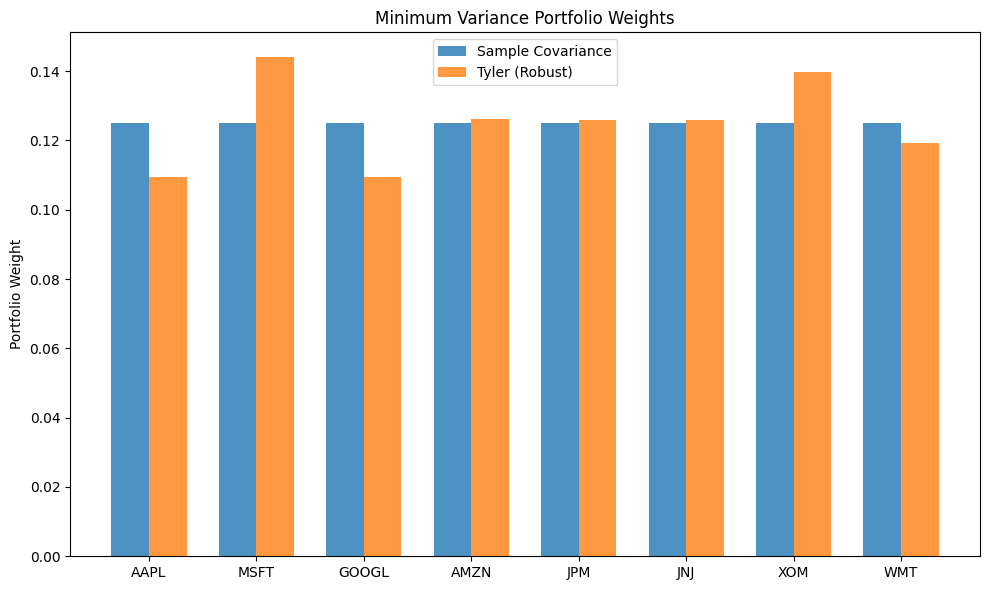

In [6]:
weights_sample = min_variance_portfolio(cov_sample)
weights_tyler = min_variance_portfolio(cov_tyler)

viz.plot_portfolio_weights(weights_sample, weights_tyler, symbols)

## 4. Backtest Portfolios

Simulate the out‑of‑sample performance using a rolling window. For simplicity, we'll do a one‑time portfolio constructed on the entire period and then evaluate returns.

In practice, you would rebalance periodically. Here we just show the cumulative returns of the static portfolios.

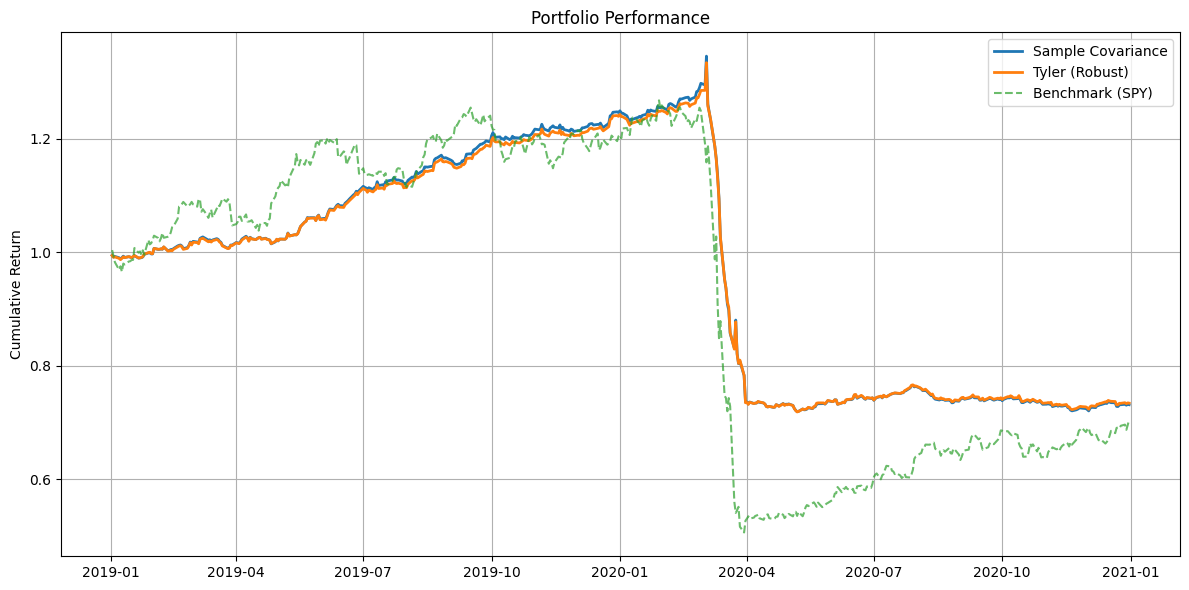

In [9]:
# Portfolio returns (daily)
port_sample = returns @ weights_sample
port_tyler = returns @ weights_tyler

# Benchmark: SPY (Extracted directly from our synthetic data)
spy_prices = prices[['SPY']]
spy_ret = compute_returns(spy_prices)

# Plotting the results (pass the 'SPY' column as a Series to the viz function)
viz.plot_cumulative_returns(port_sample, port_tyler, benchmark=spy_ret['SPY'])

## 5. Performance Metrics

Compute Sharpe ratio, volatility, and maximum drawdown to compare robustness.

In [10]:
def metrics(returns, ann_factor=252):
    vol = returns.std() * np.sqrt(ann_factor)
    sharpe = returns.mean() * ann_factor / vol
    cum = (1 + returns).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    return {'Volatility': vol, 'Sharpe': sharpe, 'Max Drawdown': mdd}

print("Sample Covariance Portfolio:")
print(metrics(port_sample))
print("\nTyler Portfolio:")
print(metrics(port_tyler))

Sample Covariance Portfolio:
{'Volatility': np.float64(0.14169399429106666), 'Sharpe': np.float64(-0.9938316723044933), 'Max Drawdown': np.float64(-0.4655482936786065)}

Tyler Portfolio:
{'Volatility': np.float64(0.1407899512846988), 'Sharpe': np.float64(-0.988468250405172), 'Max Drawdown': np.float64(-0.4613068640522483)}
